**Analyse et prédiction des notes de films :**


In [ ]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata_branch_gilles as td
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Récupération des données :

In [3]:
ids= td.get_movie_ids_list(20, headers=td.headers) # tire la premiere page des films US les plus notés, il y en a 20 par page 
df=td.get_movies_info(ids,headers=td.headers)

getting movie ids


 10%|█         | 2/20 [00:01<00:09,  1.86it/s]


KeyboardInterrupt: 

In [4]:
df.head()

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,None,160000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",https://www.warnerbros.com/movies/inception,27205,tt1375666,"[US, GB]",en,...,Released,Your mind is the scene of the crime.,Inception,False,8.370,36726,NaN,NaN,NaN,NaN
1,False,/9REO1DLpmwhrBJY3mYW5eVxkXFM.jpg,None,165000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",http://www.interstellarmovie.net/,157336,tt0816692,[US],en,...,Released,Mankind was born on Earth. It was never meant ...,Interstellar,False,8.445,35889,NaN,NaN,NaN,NaN
2,False,/oOv2oUXcAaNXakRqUPxYq5lJURz.jpg,NaN,185000000,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name...",https://www.warnerbros.com/movies/dark-knight/,155,tt0468569,[US],en,...,Released,Welcome to a world without rules.,The Dark Knight,False,8.500,33074,263.0,The Dark Knight Collection,/ogyw5LTmL53dVxsppcy8Dlm30Fu.jpg,/xyhrCEdB4XRkelfVsqXeUZ6rLHi.jpg
3,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,NaN,237000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,...,Released,Enter the world of Pandora.,Avatar,False,7.583,31627,87096.0,Avatar Collection,/uO2yU3QiGHvVp0L5e5IatTVRkYk.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg
4,False,/en971MEXui9diirXlogOrPKmsEn.jpg,NaN,58000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.20thcenturystudios.com/movies/dead...,293660,tt1431045,[US],en,...,Released,Feel the love.,Deadpool,False,7.623,31115,448150.0,Deadpool Collection,/30c5jO7YEXuF8KiWXLg9m28GWDA.jpg,/dTq7mGyAR5eAydR532feWfjJjzm.jpg


In [5]:
df1=td.drop_useless_info(df)
df1=td.keep_main_genre(df1)

Gestion des valeurs manquantes : Imputation par la moyenne 

In [6]:
df1["revenue"] = df1["revenue"].replace(0, df1["revenue"][df1["revenue"] != 0].mean())
df1["budget"] = df1["budget"].replace(0, df1["budget"][df1["budget"] != 0].mean())

Encodage de la colonne "overview" : Création d'une colonne comptant le nombre de caractères dans le synopsis


In [7]:
df1["overview_count"]=df1["overview"].map(len)

Encodage de la colonne "main_genre_name" par la méthode : "One hot encoding" 

In [8]:
for genre in df1["main_genre_name"].unique() :
    df1["main_genre_name"+"_"+str(genre)] = (df1["main_genre_name"] == genre).astype(int) 

Nous allons régresser la variable "vote_average" sur les covariables selectionnées ci-dessous : 

In [9]:
df1.head(1)

,budget,id,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,...,main_genre_name_Animation,main_genre_name_Fantasy,main_genre_name_Family,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Western,main_genre_name_History,main_genre_name_Music,main_genre_name_War,main_genre_name_Romance
0,160000000.0,27205,"Cobb, a skilled thief who commits corporate es...",117.816,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,2010-07-15,825532764.0,148,Inception,8.37,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df1["main_genre_name"].unique()
L=[]
for i in df1["main_genre_name"].unique() : 
    L.append("main_genre_name"+"_"+str(i))
var_explicative=["id","vote_average","budget","runtime","overview_count","revenue"]
var_explicative.extend(L)
df1=df1.loc[:,var_explicative]

In [72]:
df1.head()

,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Action,main_genre_name_Adventure,main_genre_name_Drama,main_genre_name_Science Fiction,...,main_genre_name_Animation,main_genre_name_Fantasy,main_genre_name_Family,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Western,main_genre_name_History,main_genre_name_Music,main_genre_name_War,main_genre_name_Romance
0,27205,8.370,160000000.0,148,280,8.255328e+08,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,157336,8.445,165000000.0,169,198,7.017292e+08,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,155,8.517,185000000.0,152,396,1.004558e+09,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,19995,7.583,237000000.0,162,175,2.923706e+09,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,293660,7.623,58000000.0,108,334,7.828373e+08,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Existe t'il une relation linéaire entre la variable expliqué et les covariables ? 

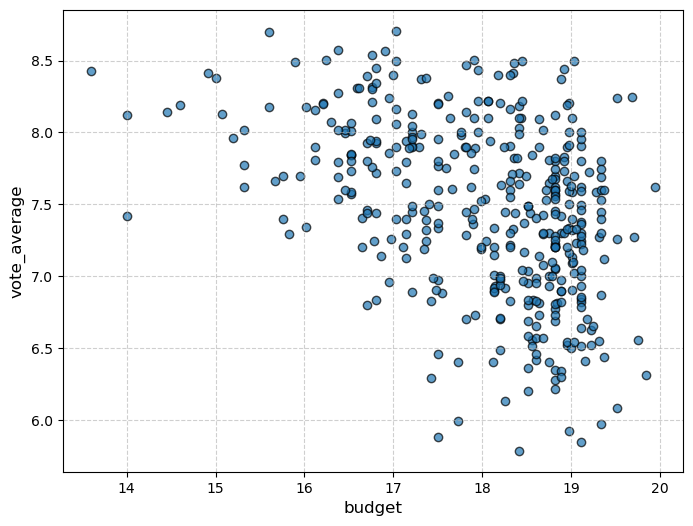

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log(df1['budget']), df1['vote_average'], alpha=0.7, edgecolor='k')

plt.title("", fontsize=14)
plt.xlabel("budget", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

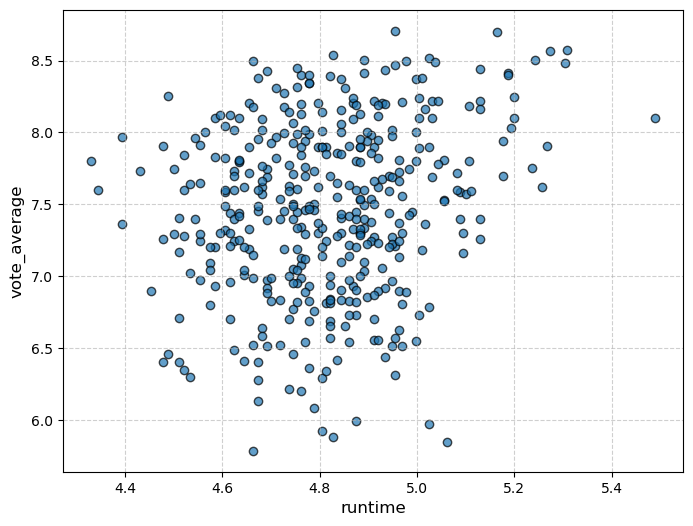

In [74]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log(df1['runtime']), df1['vote_average'], alpha=0.7, edgecolor='k')

plt.title("", fontsize=14)
plt.xlabel("runtime", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

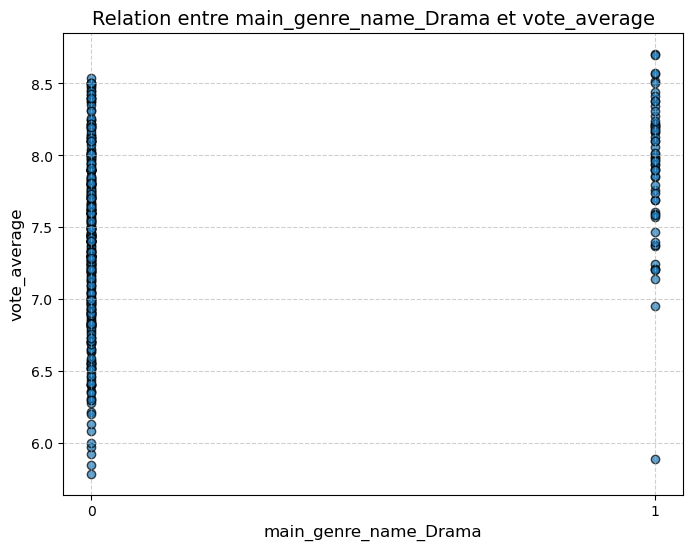

In [75]:
plt.figure(figsize=(8, 6))


plt.scatter(df1["main_genre_name_Drama"], df1['vote_average'], alpha=0.7, edgecolor='k')


plt.title("Relation entre main_genre_name_Drama et vote_average", fontsize=14)
plt.xlabel("main_genre_name_Drama", fontsize=12)
plt.ylabel("vote_average", fontsize=12)

plt.xticks([0, 1])

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Analyse descriptive de notre jeu de données : 

In [76]:
df1.describe()

,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Action,main_genre_name_Adventure,main_genre_name_Drama,main_genre_name_Science Fiction,...,main_genre_name_Animation,main_genre_name_Fantasy,main_genre_name_Family,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Western,main_genre_name_History,main_genre_name_Music,main_genre_name_War,main_genre_name_Romance
count,400.000000,400.000000,4.000000e+02,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.00000,400.00000,400.000000,400.0000,400.0000,400.000000,400.000000,400.000000
mean,129510.180000,7.466478,1.027915e+08,125.272500,292.262500,5.384871e+08,0.275000,0.167500,0.150000,0.060000,...,0.072500,0.047500,0.02500,0.02500,0.015000,0.0025,0.0025,0.005000,0.010000,0.020000
std,167714.533441,0.604642,7.950942e+07,23.109161,132.497084,4.247439e+08,0.447073,0.373889,0.357519,0.237784,...,0.259639,0.212972,0.15632,0.15632,0.121705,0.0500,0.0500,0.070622,0.099623,0.140175
min,11.000000,5.785000,8.069470e+05,76.000000,58.000000,2.859750e+06,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
25%,770.500000,7.038750,3.000000e+07,108.750000,184.750000,2.449317e+08,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
50%,46607.000000,7.492000,9.000000e+07,123.000000,280.000000,4.483672e+08,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
75%,262653.750000,7.915750,1.540000e+08,137.000000,370.250000,7.507392e+08,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
max,872585.000000,8.708000,4.600000e+08,242.000000,902.000000,2.923706e+09,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.00000,1.00000,1.000000,1.0000,1.0000,1.000000,1.000000,1.000000


/tmp/ipykernel_20855/3738631242.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:, ["vote_average", "budget", "runtime", "overview_count", "revenue", "main_genre_name_Drama"]].T, bias=True)


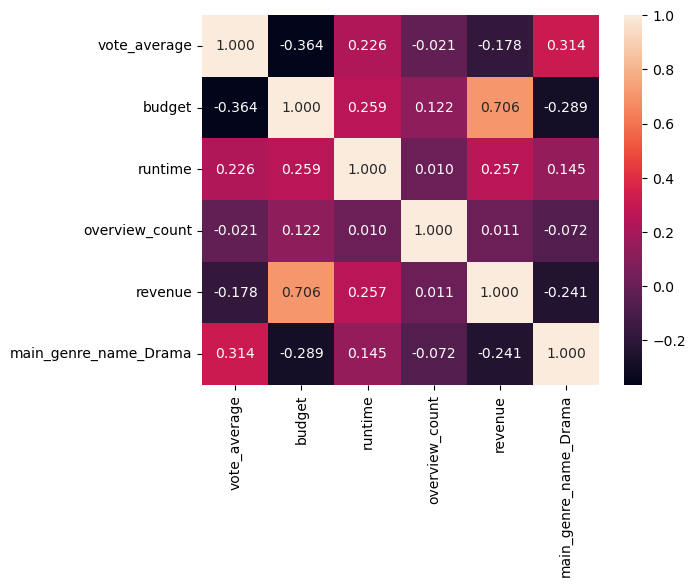

In [77]:
corr = np.corrcoef(df1.loc[:, ["vote_average", "budget", "runtime", "overview_count", "revenue", "main_genre_name_Drama"]].T, bias=True)

labs = ['vote_average', 'budget', 'runtime', 'overview_count', 'revenue', 'main_genre_name_Drama']

sns.heatmap(corr, annot=True, fmt='.3f', xticklabels=labs, yticklabels=labs)

plt.show()

NB : La normalisation et la standardisation des données n'est pas nécessaire dans la regression linéaire. En effet, contrairement au modèle de clustering, la regression linéaire ne sélectionne pas les covariables par leurs poids. 

Régression linéaire :

In [ ]:
X=df1.loc[:,~df1.columns.isin(['id', 'vote_average']) ]
Y=df1[["vote_average"]]
X.head()
Y.head()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3) # 70% de notre échantillon est utilisé pour estimer les coefs de la regression linéaire 

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Score R2 : {r2}")

Coefficients de la régression linéaire : [[-3.27329327e-09  9.60563376e-03  2.88908255e-04  1.46472708e-10
  -2.13861381e-01 -1.41040860e-01  1.44806856e-01 -2.70266453e-01
  -1.61715635e-01  1.99198378e-01  2.07231285e-01  4.76190311e-01
   1.07365433e-01 -2.87811080e-02 -1.13172693e-01 -1.76019830e-01
   5.55111512e-17  3.41468110e-01 -1.26340044e-01 -2.88731759e-01
   4.36693891e-02]]
Ordonnée à l'origine (intercept) : [6.49978869]
Erreur quadratique moyenne (MSE) : 0.24319179950297604
Score R2 : 0.3420379181597498


Remarque : les coefficients devant les covariables budget, revenue, ect ... Sont relativement petit comparé aux coefficients devant le genre car par ex la variable budget prend des valeurs très grandes.  

Distinguer les covariables ayant réellement un impact sur Y : (tests multiples de niveau 5%, rejet de H0 à tort au niv 5%) 

In [ ]:
# Ajouter une constante à X pour inclure l'intercept dans le modèle
X = sm.add_constant(X)

# Créer le modèle de régression linéaire
model = sm.OLS(Y, X).fit()  # OLS = Ordinary Least Squares (régression linéaire)

# Obtenir les résultats du modèle
summary = model.summary()

# Afficher le résumé qui contient les statistiques t de chaque covariable
print(summary)

                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     11.08
Date:                Sat, 28 Dec 2024   Prob (F-statistic):           1.99e-27
Time:                        15:13:53   Log-Likelihood:                -273.76
No. Observations:                 400   AIC:                             589.5
Df Residuals:                     379   BIC:                             673.3
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

La différence de R2 entre statmodel et sklearn vient du fait qu'on entraine nos données sur 100% des données sur statmodel vs 70% sur sklearn. Notons que les statistiques de test, sont en valeur absolu relativement élevés ce qui signifie qu'elles sont significatives. 


In [24]:
#Zone de rejet de niveau 5% pour notre test d'hypothèse (H0: B0 =0) :
var_non_explicative_significative_au_niv_5=[] 
quant = norm.ppf(1-5/200, loc=0, scale=1)
for var_explicative in X.columns:
    if  model.tvalues[var_explicative] >= quant or model.tvalues[var_explicative] <= - quant : 
        print("On rejette H0, ie que la covariable ", var_explicative, "a un impact sur la variable vote_average, ",var_explicative," est significative au niveau 5%")
    else: 
        var_non_explicative_significative_au_niv_5.append(var_explicative)
print(var_non_explicative_significative_au_niv_5)


On rejette H0, ie que la covariable  const a un impact sur la variable vote_average,  const  est significative au niveau 5%
On rejette H0, ie que la covariable  budget a un impact sur la variable vote_average,  budget  est significative au niveau 5%
On rejette H0, ie que la covariable  runtime a un impact sur la variable vote_average,  runtime  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Adventure a un impact sur la variable vote_average,  main_genre_name_Adventure  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Drama a un impact sur la variable vote_average,  main_genre_name_Drama  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Comedy a un impact sur la variable vote_average,  main_genre_name_Comedy  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Crime a un impact sur la variable vote_average,  main_genre_name_Crime  est significative a

La variable "revenue" n'est pas significative au niveau 5%, ceci peux etre expliquer par la forte correlation avec la variable "budget" (biais de la variable omise)
Pour ce qui est de la non significativité des variables de genres elle peut etre lié à un échantillon trop fiable de film correspond à ce genre. 

In [29]:
ids = td.get_balanced_movie_list(1, headers=td.headers)  # répartition égale des genres
df = td.get_movies_info(ids, headers=td.headers)
df2 = td.drop_useless_info(df)
df2 = td.keep_main_genre(df2)
df2["overview_count"] = df2["overview"].map(len)
for genre in df2["main_genre_name"].unique():
    df2["main_genre_name_" + str(genre)] = (df2["main_genre_name"] == genre).astype(int)
L = []
for i in df2["main_genre_name"].unique():
    L.append("main_genre_name_" + str(i))
var_explicative = ["id", "vote_average", "runtime", "overview_count"]
var_explicative.extend(L)
df2 = df2.loc[:, var_explicative]

getting movie ids, 19 items (=genres) to get


2it [00:01,  1.29it/s]


KeyboardInterrupt: 

In [28]:
df2

,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Action,main_genre_name_Adventure,main_genre_name_Animation,main_genre_name_Comedy,...,main_genre_name_History,main_genre_name_Horror,main_genre_name_Music,main_genre_name_Mystery,main_genre_name_Romance,main_genre_name_Science Fiction,main_genre_name_TV Movie,main_genre_name_Thriller,main_genre_name_War,main_genre_name_Western
0,1335953,0.0,43.000000,0,0,NaN,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1335860,0.0,190294.263158,238,198,NaN,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1335645,0.0,190294.263158,0,0,NaN,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1332892,0.0,190294.263158,80,847,NaN,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1331423,1.0,190294.263158,76,133,NaN,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,1140327,0.0,190294.263158,10,283,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
376,1138527,0.0,190294.263158,89,53,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
377,1137915,0.0,190294.263158,6,68,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
378,1137679,0.0,190294.263158,0,71,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [80]:
# Généralisation : 
var_explicative_significative_au_niv_5=[]
X.columns
for var_explicative in X.columns:
    if model.tvalues[var_explicative] >= quantile or model.tvalues[var_explicative] <= - quantile : 
        print("le coef théorique devant ", var_explicative , "est trop proche de 0, on le rejete")
    else: 
        print("on conserve la variable explicative:",var_explicative)
        var_explicative_significative_au_niv_5.append(var_explicative)
print(quantile)
print(var_explicative_significative_au_niv_5)
    

le coef théorique devant  const est trop proche de 0, on le rejete
le coef théorique devant  budget est trop proche de 0, on le rejete
le coef théorique devant  runtime est trop proche de 0, on le rejete
on conserve la variable explicative: overview_count
on conserve la variable explicative: revenue
on conserve la variable explicative: main_genre_name_Action
le coef théorique devant  main_genre_name_Adventure est trop proche de 0, on le rejete
le coef théorique devant  main_genre_name_Drama est trop proche de 0, on le rejete
on conserve la variable explicative: main_genre_name_Science Fiction
on conserve la variable explicative: main_genre_name_Thriller
le coef théorique devant  main_genre_name_Comedy est trop proche de 0, on le rejete
le coef théorique devant  main_genre_name_Crime est trop proche de 0, on le rejete
le coef théorique devant  main_genre_name_Animation est trop proche de 0, on le rejete
le coef théorique devant  main_genre_name_Fantasy est trop proche de 0, on le rejete

In [81]:
from itertools import combinations

def generate_combinations(elements, k):
    """
    Génère toutes les combinaisons de k éléments dans une liste donnée.
    
    :param elements: Liste d'éléments (par exemple, une liste de variables).
    :param k: Nombre d'éléments à sélectionner.
    :return: Liste de tuples, chaque tuple représentant une combinaison.
    """
    return list(combinations(elements, k))



In [82]:
print(var_explicative)

main_genre_name_Romance


1
('overview_count',)
('revenue',)
('main_genre_name_Action',)
('main_genre_name_Science Fiction',)
('main_genre_name_Thriller',)
('main_genre_name_Horror',)
('main_genre_name_Mystery',)
2
('overview_count', 'revenue')
('overview_count', 'main_genre_name_Action')
('overview_count', 'main_genre_name_Science Fiction')
('overview_count', 'main_genre_name_Thriller')
('overview_count', 'main_genre_name_Horror')
('overview_count', 'main_genre_name_Mystery')
('revenue', 'main_genre_name_Action')
('revenue', 'main_genre_name_Science Fiction')
('revenue', 'main_genre_name_Thriller')
('revenue', 'main_genre_name_Horror')
('revenue', 'main_genre_name_Mystery')
('main_genre_name_Action', 'main_genre_name_Science Fiction')
('main_genre_name_Action', 'main_genre_name_Thriller')
('main_genre_name_Action', 'main_genre_name_Horror')
('main_genre_name_Action', 'main_genre_name_Mystery')
('main_genre_name_Science Fiction', 'main_genre_name_Thriller')
('main_genre_name_Science Fiction', 'main_genre_name_H

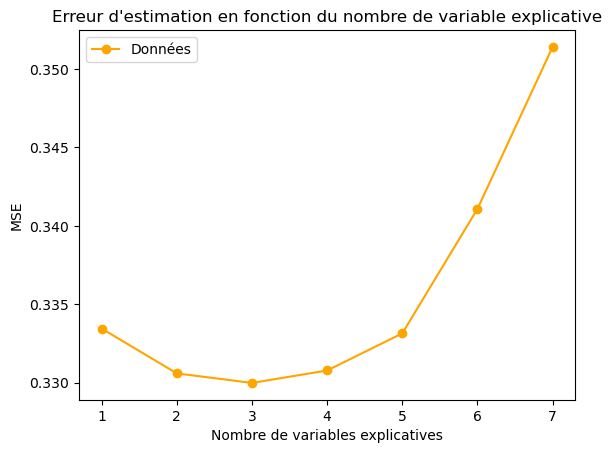

In [83]:
X=X.loc[:,var_explicative_significative_au_niv_5[:7]] #On peut enlever [:7], ici sur nos données ca explose pour une certaines vraibles il va donc falloir l'enlever
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
a=[]
b=[]
for i in range(1,len(var_explicative_significative_au_niv_5[:7])+1): #On peut enlever [:7]
    print(i)
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5[:7], i) #On peut enlever [:7]
    L=[]
    for comb in combinations_list: 
        print(comb)
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
    a.append(i)
    b.append(min(L))

import matplotlib.pyplot as plt

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()

In [84]:
X=X.loc[:,var_explicative_significative_au_niv_5] #On peut enlever [:7], ici sur nos données ca explose pour une certaines vraibles il va donc falloir l'enlever
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
a=[]
b=[]
for i in range(1,len(var_explicative_significative_au_niv_5)+1): #On peut enlever [:7]
    print(i)
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5, i) #On peut enlever [:7]
    L=[]
    for comb in combinations_list: 
        print(comb)
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
    a.append(i)
    b.append(min(L))

import matplotlib.pyplot as plt

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()

KeyError: "['main_genre_name_Western', 'main_genre_name_History', 'main_genre_name_Music', 'main_genre_name_War'] not in index"

Il est donc clair qu'il n'est pas favorable d'ajouter toutes les variables explicatives. 

Var optimum : 

In [ ]:
X=X.loc[:,var_explicative_significative_au_niv_5] 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
comb_optimum=[]
mse_min=1
for i in range(1,len(var_explicative_significative_au_niv_5)+1): 
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5, i) 
    for comb in combinations_list: 
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()
        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)
        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])
        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        if mse < mse_min:
            mse_min=mse
            comb_optimum=comb

print("Le mse min est : ",mse_min," et les variables explicatives permettant de l'atteindre sont : ",comb_optimum)

Le mse min est :  0.4715456133641778  et les variables explicatives permettant de l'atteindre sont :  ('overview_count',)


Méthode Lasso :